# Shrinkage Methods


We suppose YouTube has been running a series of **week-long randomized experiments** to test different product changes or treatments designed to increase the amount of time users spend on the platform.

In total, YouTube conducted **50 separate experiments** over the last few months. Each experiment includes:

$$
2000 \text{ users} = 1000 \text{ treated} + 1000 \text{ control}
$$

For each user, YouTube records the **change in weekly time spent on the platform compared with the previous week**.

Across all experiments, we therefore have:

$$
50 \times 2000 = 100{,}000
$$

user-level observations.

The key point is that these are **50 different experiments**, so we do not assume that they all have the same treatment effect. Instead, each experiment can have its own true effect:

$$
\beta_1,\beta_2,\ldots,\beta_{50}
$$

Normally, we could analyze each experiment separately and estimate its treatment effect using the difference between the treatment and control groups. However, because each estimate contains sampling noise, some of the estimated effects may be too high or too low simply due to random variation.

The main question in this project is therefore:

> Can we use **shrinkage methods** to borrow information across the 50 experiments and obtain more accurate treatment-effect estimates?

In other words, we will compare the usual experiment-by-experiment estimates with shrinkage-based estimates and check whether shrinkage reduces the overall estimation error.

---

## Dataset 1

This dataset contains:

$$
100{,}000 \text{ rows} \times 3 \text{ columns}
$$

| Variable            | Meaning                                                                         |
| ------------------- | ------------------------------------------------------------------------------- |
| `outcome`           | Change in a user's weekly time spent on YouTube compared with the previous week |
| `treatment`         | $1=$ treatment, $0=$ control                                                    |
| `experiment_number` | Experiment number from 1 to 50                                                  |

For example,

$$
outcome=-10
$$

means the user spent **10 fewer minutes** on YouTube than in the previous week, while

$$
outcome=15
$$

means the user spent **15 more minutes**.

---

## What do we estimate?

For each experiment $j$, we first estimate the treatment effect as:

$$
\hat{\beta}_j
=
\bar{Y}_{Treatment,j}
-
\bar{Y}_{Control,j}
$$

So we obtain 50 ordinary treatment-effect estimates:

$$
\hat{\beta}_1,\hat{\beta}_2,\ldots,\hat{\beta}_{50}
$$

These are the standard frequentist estimates that I will later compare with the shrinkage estimates.

---

## Dataset 2 

This dataset contains the **true treatment effect** for each of the 50 experiments.

In a real setting, YouTube would not know these true effects. They are provided only so we can evaluate how well the different estimation methods perform.

Therefore:

$$
\boxed{\text{we do not use the true effects to construct my estimates.}}
$$

we only use them at the end to calculate the **Mean Squared Error (MSE)**:

$$
MSE
=
\frac{1}{50}
\sum_{j=1}^{50}
\left(
\hat{\beta}_j-\beta_j^{true}
\right)^2
$$

Finally, we compare the ordinary estimates with the shrinkage estimates to determine whether shrinkage improves the accuracy of the estimated treatment effects.


## Baseline Frequentist Estimates

The first step is to create the **baseline frequentist treatment-effect estimates** before applying any shrinkage method.

For each of the 50 experiments, we estimate a separate regression:

$$
Y_i = \alpha + \beta Treatment_i + \epsilon_i
$$

where:

* $Y_i$ is the change in the user's weekly time spent on YouTube.
* $Treatment_i=1$ for treated users and $0$ for control users.
* $\hat{\beta}$ is the estimated treatment effect.

Because treatment is binary, the regression coefficient is simply the difference between the average outcomes of the treatment and control groups:

$$
\hat{\beta}_j
=
\bar{Y}_{Treatment,j}
-
\bar{Y}_{Control,j}
$$

I repeat this for all 50 experiments, which gives:

$$
\hat{\beta}_1,\hat{\beta}_2,\ldots,\hat{\beta}_{50}
$$

These 50 estimates represent the **standard frequentist estimates** and will serve as the baseline for comparison with the shrinkage methods.

### Evaluating the estimates

After estimating the treatment effects, we use the true effects from `data_Stein_Truth.csv or data set 2` **only for evaluation**.

For each experiment $j$, the estimation error is:

$$
Error_j = \hat{\beta}_j-\beta_j^{true}
$$

and the squared error is:

$$
SquaredError_j
=
(\hat{\beta}_j-\beta_j^{true})^2
$$

we then average the squared errors across all 50 experiments to calculate the **Mean Squared Error (MSE)**:

$$
\boxed{
MSE=
\frac{1}{50}
\sum_{j=1}^{50}
(\hat{\beta}_j-\beta_j^{true})^2
}
$$

For example, for experiment 1:

$$
\hat{\beta}_1=1.951
$$

while the true treatment effect is:

$$
\beta_1^{true}=2.287
$$

Therefore, its squared error is:

$$
(1.951-2.287)^2 \approx 0.113
$$

I repeat this calculation for all 50 experiments and take the average. This MSE gives me a baseline measure of accuracy that I can later compare with the James–Stein and other shrinkage estimates.


In [2]:
import pandas as pd
import statsmodels.formula.api as smf

data = pd.read_csv("data_Stein.csv")
true = pd.read_csv("data_Stein_Truth.csv")

estimates = []

# one regression for each experiment
for exp in range(1, 51):

    temp = data[data["experiment_number"] == exp]

    model = smf.ols(
        "outcome ~ treatment",
        data=temp
    ).fit()

    beta_hat = model.params["treatment"]

    estimates.append(beta_hat)

#estimates into a dataframe
results = pd.DataFrame({
    "experiment_number": range(1, 51),
    "estimated_effect": estimates
})

# true effects
results = results.merge(
    true,
    on="experiment_number"
)

# Squared error for each experiment
results["squared_error"] = (
    results["estimated_effect"] - results["true_effect"]
) ** 2

# Mean squared error
mse = results["squared_error"].mean()

print(results)
print("MSE:", mse)

    experiment_number  estimated_effect  true_effect  squared_error
0                   1          1.951373     2.287247   1.128116e-01
1                   2         -2.326794    -2.103331   4.993573e-02
2                   3          1.800648     2.151114   1.228264e-01
3                   4         -2.184088    -0.477948   2.910911e+00
4                   5          0.239095    -0.488668   5.296389e-01
5                   6          0.745346    -0.317246   1.129101e+00
6                   7          0.613068     0.405045   4.327337e-02
7                   8          3.505125     1.800193   2.906792e+00
8                   9          0.922175    -0.943145   3.479417e+00
9                  10          0.553500     1.206149   4.259506e-01
10                 11          0.173137     0.172669   2.192677e-07
11                 12          1.252400     1.405178   2.334091e-02
12                 13         -0.770822     0.615975   1.923205e+00
13                 14         -0.353392    -0.69

### Frequentist Baseline Result

Using the actual data, the Mean Squared Error of the 50 frequentist treatment-effect estimates is:

$$
\boxed{MSE_{\text{Frequentist}} \approx 1.0606}
$$

or, rounded to three decimal places:

$$
\boxed{MSE_{\text{Frequentist}} = 1.061}
$$

This gives me the **baseline performance** of the standard frequentist approach.

Later, we will estimate the same 50 treatment effects using James–Stein and other shrinkage methods and calculate their MSE in exactly the same way.

The main comparison will be whether:

$$
MSE_{\text{Shrinkage}} < 1.061
$$

If this happens, it means that the shrinkage method produces treatment-effect estimates that are, on average, closer to the true treatment effects than the standard frequentist estimates.

### No Need OLS Here

Although we could have used a regression,

$$
Y_i = \alpha + \beta Treatment_i + \epsilon_i,
$$

we do not technically need to run OLS separately for every experiment.

Because `treatment` is a binary variable ($0/1$), the estimated treatment coefficient from this regression is exactly equal to:

$$
\hat{\beta}_j
=
\bar{Y}_{Treatment,j}
-
\bar{Y}_{Control,j}
$$

Therefore, we can simply calculate the **treated mean minus the control mean** for each experiment and obtain the same 50 treatment-effect estimates that I would get from OLS.


## James–Stein Shrinkage Estimation

In this step, I take the **50 ordinary treatment-effect estimates** from the previous question and apply James–Stein shrinkage.

The main idea is to shrink each ordinary estimate toward zero:

$$
\hat{\beta}_j^{JS}
=
\delta \hat{\beta}_j
$$

where:

* $\hat{\beta}_j$ is the ordinary treatment-effect estimate for experiment $j$.
* $\delta$ is the common shrinkage factor.
* $\hat{\beta}_j^{JS}$ is the James–Stein estimate.

For example, if:

$$
\delta=0.7
$$

and the ordinary estimate is:

$$
\hat{\beta}_j=10,
$$

then the shrunken estimate becomes:

$$
\hat{\beta}_j^{JS}=10(0.7)=7.
$$

So, the smaller $\delta$ is, the more strongly the estimates are pulled toward zero.

---

### Step 1: Estimate the Noise Variance

For each experiment, the ordinary treatment-effect estimate is:

$$
\hat{\beta}_j
=
\bar{Y}_{T,j}
-
\bar{Y}_{C,j}
$$

Since the treatment and control groups are random samples, $\hat{\beta}_j$ contains sampling noise.

The estimated sampling variance of the treatment effect is:

$$
Var(\hat{\beta}_j)
=
\frac{s_{T,j}^2}{n_T}
+
\frac{s_{C,j}^2}{n_C}
$$

where:

$$
n_T=n_C=1000.
$$

I calculate this variance separately for all 50 experiments using only the experimental data.

Because the basic James–Stein formula assumes a common noise variance, I take the average of the 50 estimated variances:

$$
\hat{\sigma}^2
=
\frac{1}{50}
\sum_{j=1}^{50}
Var(\hat{\beta}_j)
$$

For this dataset:

$$
\boxed{\hat{\sigma}^2 \approx 0.799}
$$

---

### Step 2: Calculate the James–Stein Shrinkage Factor

The shrinkage factor is:

$$
\delta
=
1-
\frac{(p-2)\hat{\sigma}^2}
{\sum_{j=1}^{p}\hat{\beta}_j^2}
$$

where the number of treatment-effect estimates is:

$$
p=50.
$$

Using the estimated effects and noise variance from the data, I obtain:

$$
\boxed{\delta \approx 0.731}
$$

Therefore, every ordinary treatment-effect estimate is multiplied by approximately $0.731$.

For example, for experiment 1:

$$
\hat{\beta}_1=1.951
$$

so the James–Stein estimate is:

$$
\hat{\beta}_1^{JS}
=
1.951(0.731)
\approx
1.426.
$$

I repeat this for all 50 experiments to obtain:

$$
\hat{\beta}_1^{JS},
\hat{\beta}_2^{JS},
\ldots,
\hat{\beta}_{50}^{JS}.
$$

---

### Step 3: Evaluate the James–Stein Estimates

Only after creating the James–Stein estimates do I use the true treatment effects from the second dataset.

The James–Stein MSE is:

$$
\boxed{
MSE_{JS}
=
\frac{1}{50}
\sum_{j=1}^{50}
\left(
\hat{\beta}_j^{JS}
-
\beta_j^{true}
\right)^2
}
$$

I can then compare this with the frequentist baseline:

$$
MSE_{\text{Frequentist}}=1.061.
$$

If:

$$
MSE_{JS}<1.061,
$$

then the James–Stein shrinkage estimates are, on average, closer to the true treatment effects than the original experiment-by-experiment estimates.


In [3]:
import numpy as np

betas = []
variances = []

# Estimating treatment effect and its variance for each experiment
for exp in range(1, 51):

    temp = data[data["experiment_number"] == exp]

    treated = temp[temp["treatment"] == 1]["outcome"]
    control = temp[temp["treatment"] == 0]["outcome"]

    # Frequentist treatment effect
    beta_hat = treated.mean() - control.mean()

    # Variance of treatment effect estimate
    var_beta = (
        treated.var() / len(treated)
        + control.var() / len(control)
    )

    betas.append(beta_hat)
    variances.append(var_beta)

betas = np.array(betas)

# Common sampling variance
sigma2 = np.mean(variances)

# Number of experiments
p = 50

# James-Stein shrinkage factor
delta = 1 - ((p - 2) * sigma2) / np.sum(betas**2)

print("Estimated variance:", sigma2)
print("Shrinkage factor:", delta)

# James-Stein estimates
js_betas = delta * betas


results = pd.DataFrame({
    "experiment_number": range(1, 51),
    "frequentist_effect": betas,
    "JS_effect": js_betas
})

# True effects are used ONLY for evaluation
results = results.merge(true, on="experiment_number")

# MSE
results["squared_error_JS"] = (
    results["JS_effect"] - results["true_effect"]
) ** 2

mse_js = results["squared_error_JS"].mean()

print(results)
print("James-Stein MSE:", mse_js)

Estimated variance: 0.7989724036744791
Shrinkage factor: 0.7306943837823665
    experiment_number  frequentist_effect  JS_effect  true_effect  \
0                   1            1.951373   1.425857     2.287247   
1                   2           -2.326794  -1.700175    -2.103331   
2                   3            1.800648   1.315723     2.151114   
3                   4           -2.184088  -1.595901    -0.477948   
4                   5            0.239095   0.174705    -0.488668   
5                   6            0.745346   0.544620    -0.317246   
6                   7            0.613068   0.447965     0.405045   
7                   8            3.505125   2.561175     1.800193   
8                   9            0.922175   0.673828    -0.943145   
9                  10            0.553500   0.404439     1.206149   
10                 11            0.173137   0.126510     0.172669   
11                 12            1.252400   0.915122     1.405178   
12                 13      

## James–Stein Results

The estimated common noise variance is:

$$
\boxed{\hat{\sigma}^2=0.799}
$$

The James–Stein shrinkage factor is:

$$
\boxed{\delta=0.731}
$$

After shrinking the 50 treatment-effect estimates, the resulting MSE is:

$$
\boxed{MSE_{JS}=0.625}
$$

This is lower than the frequentist baseline:

$$
MSE_{\text{Frequentist}}=1.061
$$

so the James–Stein estimates are more accurate overall for these experiments.

Importantly, the true treatment effects are **not used to calculate $\delta$**. They are used only afterward to evaluate performance through MSE.


## Split-Sample Shrinkage

In this approach, I use the data itself to learn **how much the 50 treatment effects should be shrunk**.

### Step 1: Split Each Experiment

Each experiment contains:

$$
1000 \text{ treated} + 1000 \text{ control}
$$

I divide each experiment into two independent halves, each with roughly:

$$
500 \text{ treated} + 500 \text{ control}
$$

For experiment $j$, I estimate:

$$
\hat{\beta}_{j,A}
=
\bar{Y}_{T,A}-\bar{Y}_{C,A}
$$

and

$$
\hat{\beta}_{j,B}
=
\bar{Y}_{T,B}-\bar{Y}_{C,B}
$$

Both estimates target the same true treatment effect $\beta_j$, but use different halves of the data.

### Step 2: Learn the Shrinkage Relationship

After doing this for all 50 experiments, I regress the second-half estimates on the first-half estimates:

$$
\boxed{
\hat{\beta}_{j,B}
=
a+b\hat{\beta}_{j,A}+u_j
}
$$

where:

* $a$ is the intercept.
* $b$ is the learned shrinkage slope.

If $b$ is close to 1, the treatment effects reproduce well across the two halves, so little shrinkage is needed.

If $b$ is close to 0, the first-half estimates contain substantial noise, so stronger shrinkage is appropriate.

### Step 3: Apply Shrinkage to the Full-Sample Estimates

The half-sample estimates are used only to learn $a$ and $b$. For the final estimates, I return to the full-sample treatment effects from Question 1:

$$
\hat{\beta}_j^{full}
$$

and calculate:

$$
\boxed{
\hat{\beta}_j^{EB}
=
a+b\hat{\beta}_j^{full}
}
$$

Finally, I evaluate these estimates using:

$$
MSE_{EB}
=
\frac{1}{50}
\sum_{j=1}^{50}
\left(
\hat{\beta}_j^{EB}
-
\beta_j^{true}
\right)^2
$$

The true treatment effects are used **only for the final MSE evaluation**, not to learn the shrinkage relationship.


In [21]:
import statsmodels.api as sm

rng = np.random.default_rng(42)

results = []

for exp in range(1, 51):

    temp = data[data["experiment_number"] == exp]

    # Separate treatment and control
    treated_idx = temp[temp["treatment"] == 1].index.to_numpy()
    control_idx = temp[temp["treatment"] == 0].index.to_numpy()

    # Randomly shuffle
    rng.shuffle(treated_idx)
    rng.shuffle(control_idx)

    # Splitting each into two halves
    treated_A = treated_idx[:500]
    treated_B = treated_idx[500:]

    control_A = control_idx[:500]
    control_B = control_idx[500:]

    # Treatment effect in first half
    beta_A = (
        data.loc[treated_A, "outcome"].mean()
        - data.loc[control_A, "outcome"].mean()
    )

    # Treatment effect in second half
    beta_B = (
        data.loc[treated_B, "outcome"].mean()
        - data.loc[control_B, "outcome"].mean()
    )

    # Full-sample treatment effect
    beta_full = (
        temp[temp["treatment"] == 1]["outcome"].mean()
        - temp[temp["treatment"] == 0]["outcome"].mean()
    )

    results.append([exp, beta_A, beta_B, beta_full])


results = pd.DataFrame(
    results,
    columns=[
        "experiment_number",
        "beta_A",
        "beta_B",
        "beta_full"
    ]
)

# Regressing second-half effects on first-half effects
X = sm.add_constant(results["beta_A"])

model = sm.OLS(results["beta_B"], X).fit()

a = model.params["const"]
b = model.params["beta_A"]

print("Intercept:", a)
print("Shrinkage slope:", b)

# Applying shrinkage model to full-sample estimates
results["beta_split"] = (
    a + b * results["beta_full"]
)


split_effects = results["beta_split"].to_numpy()

# Merging true treatment effects
results = results.merge(
    true,
    on="experiment_number"
)

# MSE
results["squared_error"] = (
    results["beta_split"]
    - results["true_effect"]
) ** 2

mse = results["squared_error"].mean()

print("MSE:", mse)

Intercept: 0.2054223602547917
Shrinkage slope: 0.6534191331484934
MSE: 0.6299098439243346


### Split-Sample Shrinkage Results

The estimated shrinkage model is:

$$
\hat{\beta}_j^{EB}
=
0.205
+
0.653\hat{\beta}_j^{full}
$$

with:

$$
\boxed{a=0.205}
$$

$$
\boxed{b=0.653}
$$

$$
\boxed{MSE=0.630}
$$

The slope of $0.653$ means the original treatment effects are shrunk substantially toward the intercept rather than being used at their full size.

The MSE of $0.630$ is much lower than the frequentist baseline:

$$
1.061
$$

and is very close to the James–Stein result:

$$
MSE_{JS}=0.625.
$$

So the split-sample shrinkage also improves the accuracy of the treatment-effect estimates substantially.


## LASSO Shrinkage

In this step, I use **LASSO regression** to shrink the treatment-effect estimates toward zero.

For each experiment $j$:

$$
Y_i=\beta_{0j}+\beta_{1j}T_i+\epsilon_i
$$

LASSO estimates the treatment effect by minimizing:

$$
\frac{1}{2n}\sum_{i=1}^{n}(Y_i-\beta_0-\beta_1T_i)^2
+
\alpha|\beta_1|
$$

The intercept is not penalized. A larger $\alpha$ creates stronger shrinkage:

$$
\alpha\uparrow
\quad\Rightarrow\quad
|\hat{\beta}_1|\downarrow
$$

### Step 1: Select $\alpha$ Using 2-Fold Cross-Validation

I test the given values:

$$
\alpha\in
[0.001,0.005,0.01,0.05,0.1,0.5,1,5,10,50,100,500,1000]
$$

For each experiment, I split the 2,000 users into two halves:

* Train on half A and predict half B.
* Train on half B and predict half A.
* Average the two prediction MSEs.

Then I average this MSE across all 50 experiments:

$$
CV(\alpha)
=
\frac{1}{50}
\sum_{j=1}^{50}
MSE_j(\alpha)
$$

I choose the value with the lowest cross-validation error:

$$
\boxed{
\alpha^*=\arg\min_{\alpha}CV(\alpha)
}
$$

Importantly, the **true treatment effects are not used to select $\alpha$**. Cross-validation uses the observed outcomes $Y$.

### Step 2: Estimate the Final Treatment Effects

After selecting $\alpha^*$, I fit LASSO using all 2,000 users in each experiment and obtain:

$$
\hat{\beta}_1^{LASSO},
\ldots,
\hat{\beta}_{50}^{LASSO}
$$

Finally, I use the true effects only to evaluate accuracy:

$$
\boxed{
MSE_{LASSO}
=
\frac{1}{50}
\sum_{j=1}^{50}
(\hat{\beta}_j^{LASSO}-\beta_j^{true})^2
}
$$


In [8]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



# Alpha values 
alphas = [
    0.001, 0.005, 0.01, 0.05, 0.1,
    0.5, 1, 5, 10, 50, 100, 500, 1000
]


# creating the same two folds
# for every alpha

experiments = {}
folds = {}

for exp in range(1, 51):

    temp = data[
        data["experiment_number"] == exp
    ].reset_index(drop=True)

    experiments[exp] = temp

    indices = np.arange(len(temp))

    fold_A, fold_B = train_test_split(
        indices,
        test_size=0.5,
        random_state=42
    )

    folds[exp] = (fold_A, fold_B)


# Cross-validation for each alpha

alpha_errors = {}

for alpha in alphas:

    experiment_errors = []

    for exp in range(1, 51):

        temp = experiments[exp]
        fold_A, fold_B = folds[exp]

        fold_errors = []

        # A -> B and B -> A
        for train_idx, test_idx in [
            (fold_A, fold_B),
            (fold_B, fold_A)
        ]:

            X_train = temp.loc[
                train_idx, ["treatment"]
            ]

            y_train = temp.loc[
                train_idx, "outcome"
            ]

            X_test = temp.loc[
                test_idx, ["treatment"]
            ]

            y_test = temp.loc[
                test_idx, "outcome"
            ]

            model = Lasso(
                alpha=alpha,
                fit_intercept=True
            )

            model.fit(X_train, y_train)

            predictions = model.predict(X_test)

            mse = mean_squared_error(
                y_test,
                predictions
            )

            fold_errors.append(mse)

        # Average of the two folds
        experiment_errors.append(
            np.mean(fold_errors)
        )

    # Average across all 50 experiments
    alpha_errors[alpha] = np.mean(
        experiment_errors
    )


# Best alpha
best_alpha = min(
    alpha_errors,
    key=alpha_errors.get
)

print("Best alpha:", best_alpha)
print("CV MSE:", alpha_errors[best_alpha])

Best alpha: 0.5
CV MSE: 400.3476781634399


In [10]:
lasso_effects = []

for exp in range(1, 51):

    temp = experiments[exp]

    X = temp[["treatment"]]
    y = temp["outcome"]

    model = Lasso(
        alpha=best_alpha,
        fit_intercept=True
    )

    model.fit(X, y)

    # Treatment coefficient
    beta_hat = model.coef_[0]

    lasso_effects.append(beta_hat)


results = pd.DataFrame({
    "experiment_number": range(1, 51),
    "lasso_effect": lasso_effects
})


# Adding true effects only for final evaluation
results = results.merge(
    true,
    on="experiment_number"
)


results["squared_error"] = (
    results["lasso_effect"]
    - results["true_effect"]
) ** 2


lasso_mse = results["squared_error"].mean()

print("Final LASSO MSE:", lasso_mse)

Final LASSO MSE: 0.8882662472605213


### LASSO Results

The best penalty selected by 2-fold cross-validation is:

$$
\boxed{\alpha^*=0.5}
$$

with cross-validation prediction error:

$$
\boxed{CV\ MSE=400.348}
$$

Using $\alpha=0.5$ and refitting LASSO on the full data for each experiment gives:

$$
\boxed{MSE_{LASSO}=0.888}
$$

This is lower than the frequentist baseline:

$$
1.061
$$

so LASSO improves the treatment-effect estimates overall.

However, its MSE is higher than James–Stein and split-sample shrinkage:

$$
0.888 > 0.625 \text{ and } 0.630.
$$

So in this dataset, LASSO helps, but the other shrinkage methods perform better.


## Ridge Shrinkage

This step is very similar to LASSO, but I now use **Ridge regression** to shrink the treatment-effect estimates.

For each experiment:

$$
Y_i=\beta_0+\beta_1T_i+\epsilon_i
$$

Ridge minimizes:

$$
\sum_i(Y_i-\beta_0-\beta_1T_i)^2+\alpha\beta_1^2
$$

Unlike LASSO, Ridge generally does not set the treatment effect exactly to zero. Instead, it **continuously shrinks the coefficient toward zero**.

### Step 1: Select $\alpha$ with 2-Fold Cross-Validation

I test:

$$
\alpha \in
[0.001,0.005,0.01,0.05,0.1,0.5,1,5,10,50,100,500,1000]
$$

For each experiment and each $\alpha$:

* Train on half A and validate on half B.
* Train on half B and validate on half A.
* Average the two prediction MSEs.

Then I average across all 50 experiments:

$$
CV(\alpha)
=
\frac{1}{50}
\sum_{j=1}^{50}CV_j(\alpha)
$$

and choose:

$$
\boxed{
\alpha^*
=
\arg\min_\alpha CV(\alpha)
}
$$

The true treatment effects are **not used to choose $\alpha$**.

### Step 2: Estimate the Final Treatment Effects

Using the selected $\alpha^*$, I refit Ridge on all 2,000 users in each experiment and obtain:

$$
\hat{\beta}_1^{Ridge},\ldots,\hat{\beta}_{50}^{Ridge}
$$

Finally, I compare them with the true effects using:

$$
\boxed{
MSE_{Ridge}
=
\frac{1}{50}
\sum_{j=1}^{50}
\left(
\hat{\beta}_j^{Ridge}-\beta_j^{true}
\right)^2
}
$$


In [11]:
from sklearn.linear_model import Ridge

alphas = [
    0.001, 0.005, 0.01, 0.05, 0.1,
    0.5, 1, 5, 10, 50, 100, 500, 1000
]


experiments = {}
folds = {}

for exp in range(1, 51):

    temp = data[
        data["experiment_number"] == exp
    ].reset_index(drop=True)

    experiments[exp] = temp

    indices = np.arange(len(temp))

    fold_A, fold_B = train_test_split(
        indices,
        test_size=0.5,
        random_state=42
    )

    folds[exp] = (fold_A, fold_B)


# Cross-validation
alpha_errors = {}

for alpha in alphas:

    experiment_errors = []

    for exp in range(1, 51):

        temp = experiments[exp]
        fold_A, fold_B = folds[exp]

        fold_errors = []

        # A -> B and B -> A
        for train_idx, test_idx in [
            (fold_A, fold_B),
            (fold_B, fold_A)
        ]:

            X_train = temp.loc[
                train_idx, ["treatment"]
            ]

            y_train = temp.loc[
                train_idx, "outcome"
            ]

            X_test = temp.loc[
                test_idx, ["treatment"]
            ]

            y_test = temp.loc[
                test_idx, "outcome"
            ]

            model = Ridge(
                alpha=alpha,
                fit_intercept=True
            )

            model.fit(X_train, y_train)

            predictions = model.predict(X_test)

            mse = mean_squared_error(
                y_test,
                predictions
            )

            fold_errors.append(mse)

        experiment_errors.append(
            np.mean(fold_errors)
        )

    alpha_errors[alpha] = np.mean(
        experiment_errors
    )


# Best alpha
best_alpha = min(
    alpha_errors,
    key=alpha_errors.get
)

print("Best alpha:", best_alpha)
print("CV MSE:", alpha_errors[best_alpha])

Best alpha: 100
CV MSE: 400.326484970718


In [12]:
ridge_effects = []

for exp in range(1, 51):

    temp = experiments[exp]

    X = temp[["treatment"]]
    y = temp["outcome"]

    model = Ridge(
        alpha=best_alpha,
        fit_intercept=True
    )

    model.fit(X, y)

    beta_hat = model.coef_[0]

    ridge_effects.append(beta_hat)


results = pd.DataFrame({
    "experiment_number": range(1, 51),
    "ridge_effect": ridge_effects
})


results = results.merge(
    true,
    on="experiment_number"
)


results["squared_error"] = (
    results["ridge_effect"]
    - results["true_effect"]
) ** 2


ridge_mse = results["squared_error"].mean()

print("Ridge MSE:", ridge_mse)

Ridge MSE: 0.742337941625926


### Ridge Results

Using the same 2-fold split with `random_state=42`, the best penalty is:

$$
\boxed{\alpha^*=100}
$$

with cross-validation prediction error:

$$
\boxed{CV\ MSE \approx 400.326}
$$

After refitting Ridge on the full data for each experiment, the treatment-effect MSE is:

$$
\boxed{MSE_{Ridge}\approx0.742}
$$

This is lower than the frequentist baseline:

$$
1.061
$$

and also lower than LASSO:

$$
0.888.
$$

However, it is still slightly higher than James–Stein and split-sample shrinkage:

$$
0.742 > 0.625 \text{ and } 0.630.
$$


## Combining the Shrinkage Estimates

To compare the shrinkage approaches with the ordinary frequentist estimates, I first combine the four shrinkage estimates for each experiment.

For experiment $j$, I calculate:

$$
\boxed{
\hat{\beta}_j^{Avg}
=
\frac{
\hat{\beta}_j^{JS}
+
\hat{\beta}_j^{Split}
+
\hat{\beta}_j^{Lasso}
+
\hat{\beta}_j^{Ridge}
}{4}
}
$$

This gives me one **average shrinkage estimate** for each of the 50 experiments.

### Calculate the Estimation Errors

I then calculate the difference between each estimate and its true treatment effect.

For the frequentist estimates:

$$
Error_j^{Freq}
=
\hat{\beta}_j^{Freq}-\beta_j^{true}
$$

For the average shrinkage estimates:

$$
Error_j^{Avg}
=
\hat{\beta}_j^{Avg}-\beta_j^{true}
$$

Here, I keep the actual errors rather than squaring them because I want to examine their **distribution**.

### Compare the Error Distributions

Finally, I plot the density of:

* the 50 frequentist errors
* the 50 average-shrinkage errors

on the same graph.

An estimator performs better when its errors are more tightly concentrated around:

$$
\boxed{0}
$$

Therefore, I use the density plot to visually compare whether combining the shrinkage methods produces estimates that are more centered and less dispersed around the true treatment effects.


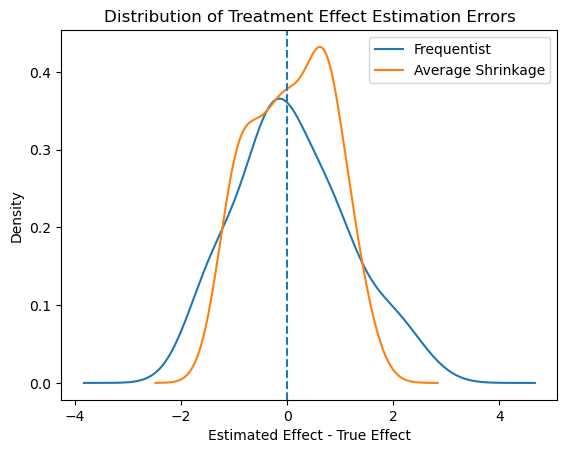

In [22]:
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "experiment_number": range(1, 51),
    "frequentist": betas,
    "james_stein": js_betas,
    "split_sample": split_effects,
    "lasso": lasso_effects,
    "ridge": ridge_effects
})

# true effects
comparison = comparison.merge(
    true,
    on="experiment_number"
)

# Average of the four shrinkage estimates
comparison["average_shrinkage"] = (
    comparison["james_stein"]
    + comparison["split_sample"]
    + comparison["lasso"]
    + comparison["ridge"]
) / 4

# Errors
comparison["frequentist_error"] = (
    comparison["frequentist"]
    - comparison["true_effect"]
)

comparison["average_error"] = (
    comparison["average_shrinkage"]
    - comparison["true_effect"]
)

# Density plot
comparison["frequentist_error"].plot(
    kind="kde",
    label="Frequentist"
)

comparison["average_error"].plot(
    kind="kde",
    label="Average Shrinkage"
)

plt.axvline(0, linestyle="--")

plt.xlabel("Estimated Effect - True Effect")
plt.ylabel("Density")
plt.title("Distribution of Treatment Effect Estimation Errors")

plt.legend()
plt.show()

## Density Plot Interpretation

The density plot shows that the **average shrinkage errors are more concentrated around zero** than the frequentist errors.

The frequentist distribution is wider, which means the ordinary estimates have **higher variability** across the 50 experiments.

The average shrinkage distribution is narrower, suggesting that combining the four shrinkage methods produces **more stable and generally more accurate treatment-effect estimates**.

However, the shrinkage distribution is slightly shifted to the right of zero, which suggests a small tendency to **overestimate the true treatment effects**.

Overall, the plot indicates that shrinkage reduces estimation variance compared with the standard frequentist approach.

## Conclusion

The standard frequentist approach is simple and transparent, but it treats each experiment independently and therefore has relatively high variance. In this analysis, it had the largest MSE:

$$
MSE_{Freq} \approx 1.061
$$

James–Stein shrinkage substantially improved the estimates by shrinking noisy effects toward zero:

$$
MSE_{JS} \approx 0.625
$$

The split-sample shrinkage approach learned the shrinkage strength directly from the data and also performed very well:

$$
MSE_{Split} \approx 0.630
$$

LASSO reduced the error compared with the frequentist approach, but performed worse than the other shrinkage methods:

$$
MSE_{LASSO} \approx 0.888
$$

Ridge provided smoother shrinkage and achieved:

$$
MSE_{Ridge} \approx 0.742
$$

Overall, all four shrinkage methods improved on the frequentist baseline. Among them, **James–Stein had the lowest MSE**, although the split-sample method performed almost equally well.